<a href="https://colab.research.google.com/github/sasirajesh/FedXGB-OptDP/blob/main/EEG_WOERK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 1.4 MB/s eta 0:00:00



🔹 Training Client 1
100%|██████████| 15/15 [00:02<00:00,  5.82trial/s, best loss: -0.9759839893262174]
Client 1 → Acc: 0.9446, F1: 0.9440

🔹 Training Client 2
100%|██████████| 15/15 [00:01<00:00,  9.37trial/s, best loss: -0.9412550066755674]
Client 2 → Acc: 0.8965, F1: 0.9164

🔹 Training Client 3
100%|██████████| 15/15 [00:01<00:00, 10.17trial/s, best loss: -0.9759679572763685]
Client 3 → Acc: 0.9680, F1: 0.9302

✅ Final Aggregation Results:
Average Accuracy: 0.9364
Average F1-score: 0.9302
Consensus Top Features: [ 2  6 10  8 13 11  5  3  9 12]


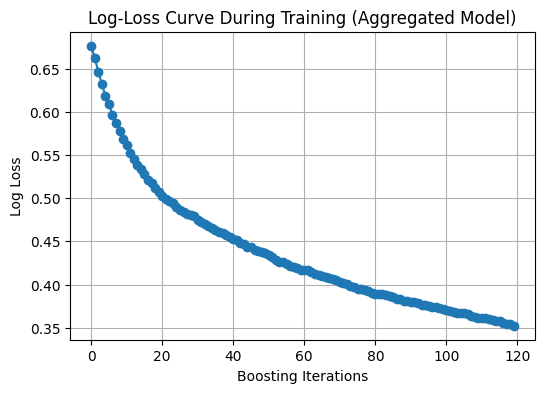

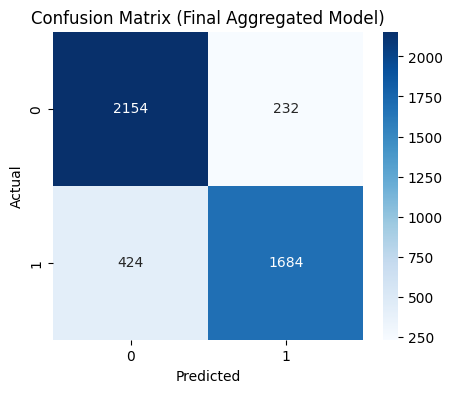

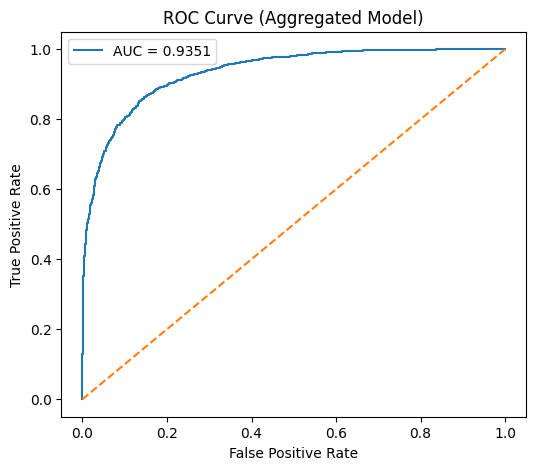

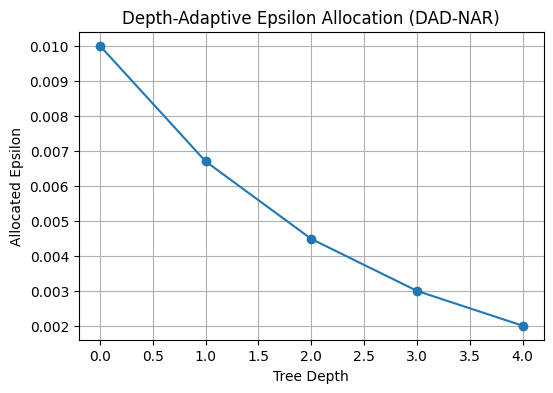

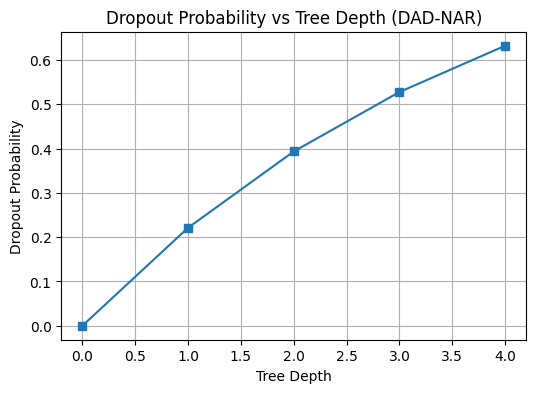

In [ ]:
# ==========================================
# 0️⃣ Imports & Setup
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random
import warnings
warnings.filterwarnings('ignore')

# Seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"  # <-- change if needed
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split among clients
num_clients = 3
client_data = np.array_split(X, num_clients)
client_labels = np.array_split(y, num_clients)

# ==========================================
# 2️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 100
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.0
epsilon_local = 1.0

# ==========================================
# 3️⃣ Helper Functions
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 4️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=10, n_pop=10, k_features=10):
    n_features = X.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)
        clf = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_individual = tools.selBest(pop, k=1)[0]
    top_k_idx = np.argsort(best_individual)[-k_features:]
    return top_k_idx

# ==========================================
# 5️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=SEED,
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials)
    return best

# ==========================================
# 6️⃣ Local Client Training (with proper split)
# ==========================================
def train_client_model(X, y):
    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X, y)
    top_features = ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10)
    X_sel = X[:, top_features]

    # Proper unseen split
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)

    # Simulate DP adjustments
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        lambda_depth = noise_aware_lambda(eps_depth)
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {
        'model': model,
        'top_features': top_features,
        'hyperparams': best_params,
        'acc': acc,
        'f1': f1
    }

# ==========================================
# 7️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation (no retraining)
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])

all_features = np.concatenate([r['top_features'] for r in clients_results])
(consensus_features, counts) = np.unique(all_features, return_counts=True)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_features_final}")
# ==========================================
# 9️⃣ Additional Visualizations (Requested)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier

# ----- 1) Correlation Heatmap -----
# X_all is defined later in the code
# plt.figure(figsize=(10,8))
# corr = pd.DataFrame(X_all).corr()
# sns.heatmap(corr, cmap="coolwarm", center=0)
# plt.title("Correlation Heatmap of EEG Features")
# plt.show()

# ==========================================
# Train Aggregated Model for Logloss + CM + ROC
# ==========================================
X_all = np.vstack(client_data)
y_all = np.hstack(client_labels)
X_all_sel = X_all[:, top_features_final]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_all_sel, y_all, test_size=0.3, random_state=SEED
)

final_model = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    eval_metric='logloss'
)

# Record training logloss
eval_results = {}
final_model.fit(
    X_train_f, y_train_f,
    eval_set=[(X_test_f, y_test_f)],
    # eval_metric="logloss", # Remove eval_metric from fit
    verbose=False
)

results = final_model.evals_result()
logloss_curve = results['validation_0']['logloss']

# ----- 3) Log-Loss Curve -----
plt.figure(figsize=(6,4))
plt.plot(logloss_curve, marker='o')
plt.title("Log-Loss Curve During Training (Aggregated Model)")
plt.xlabel("Boosting Iterations")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

# ----- 4) Confusion Matrix (Aggregated Model) -----
final_preds = final_model.predict(X_test_f)
cm = confusion_matrix(y_test_f, final_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Final Aggregated Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----- 5) ROC Curve -----
probs = final_model.predict_proba(X_test_f)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_f, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Aggregated Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ==========================================
# 10️⃣ Epsilon Adaptive Behavior (DAD-NAR)
# ==========================================
depths = list(range(max_depth))
eps_values = [depth_adaptive_epsilon(epsilon_local/num_trees, d) for d in depths]
drop_values = [dropout_probability(d) for d in depths]

# ----- 6) Epsilon Decay over Depth -----
plt.figure(figsize=(6,4))
plt.plot(depths, eps_values, marker='o')
plt.title("Depth-Adaptive Epsilon Allocation (DAD-NAR)")
plt.xlabel("Tree Depth")
plt.ylabel("Allocated Epsilon")
plt.grid()
plt.show()

# ----- 7) Dropout Probability Curve -----
plt.figure(figsize=(6,4))
plt.plot(depths, drop_values, marker='s')
plt.title("Dropout Probability vs Tree Depth (DAD-NAR)")
plt.xlabel("Tree Depth")
plt.ylabel("Dropout Probability")
plt.grid()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

file_path = "/content/csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


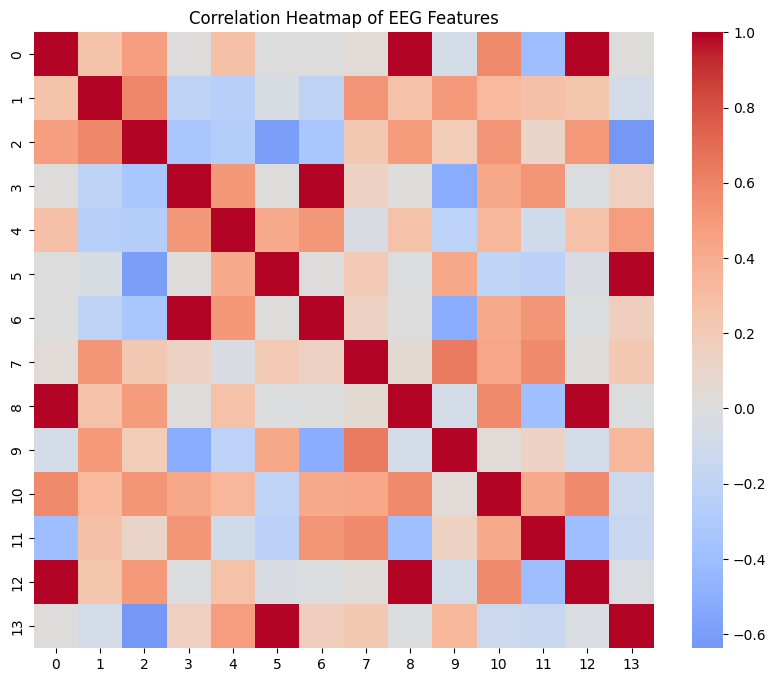

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Define X (copied from previous data loading cell) ---
file_path = "/content/csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values # y is not used here but kept for completeness

scaler = StandardScaler()
X = scaler.fit_transform(X)
# -----------------------------------------------------

plt.figure(figsize=(10,8))
corr = pd.DataFrame(X).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of EEG Features")
plt.show()

Dataset Shape: (14980, 15)


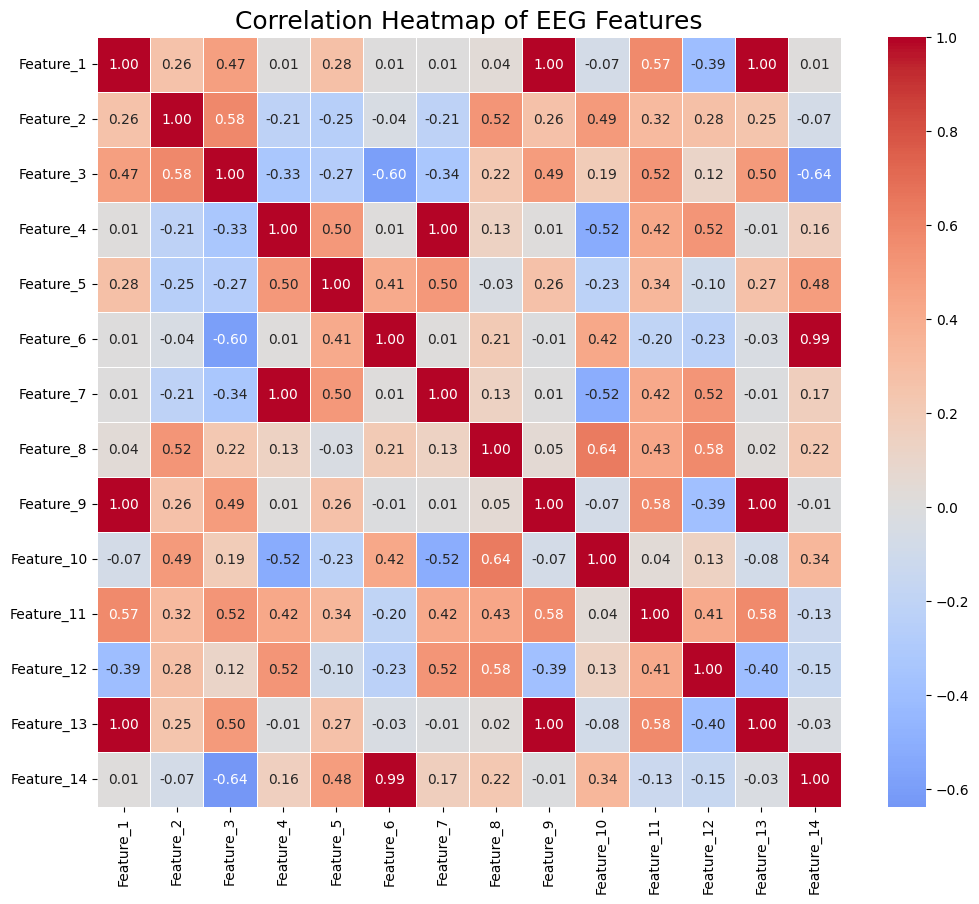

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"   # Change if needed
df = pd.read_excel(file_path)

# Print dataset info
print("Dataset Shape:", df.shape)

# ==========================================
# 2) Extract Features (X) and Label (y)
# ==========================================
X = df.iloc[:, :-1].values     # All columns except last
y = df.iloc[:, -1].values      # Last column (not used here)

# ==========================================
# 3) Feature Scaling (Standardization)
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert to DataFrame so columns have names like Feature1, Feature2...
df_features = pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])

# ==========================================
# 4) Correlation Matrix + Heatmap
# ==========================================
corr = df_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,        # ✅ Show numbers inside heatmap
    fmt=".2f",         # ✅ Values keep 2 decimal points
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of EEG Features", fontsize=18)
plt.show()


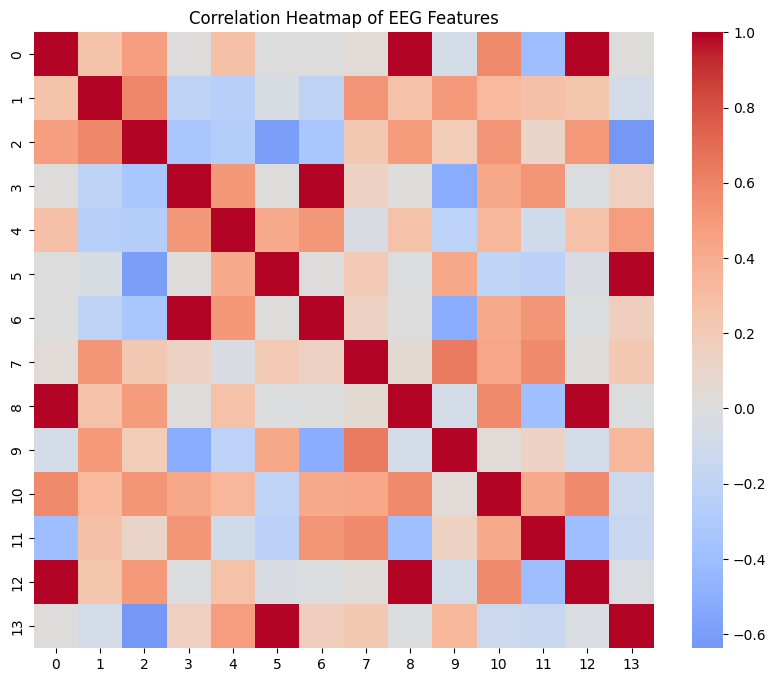

Training Client 1
100%|██████████| 10/10 [00:01<00:00,  7.34trial/s, best loss: -0.9753168779186124]
ACC=0.9493, F1=0.9487
Training Client 2
100%|██████████| 10/10 [00:01<00:00,  8.34trial/s, best loss: -0.9459279038718291]
ACC=0.8932, F1=0.9141
Training Client 3
100%|██████████| 10/10 [00:01<00:00,  7.84trial/s, best loss: -0.9773030707610146]
ACC=0.9640, F1=0.9211


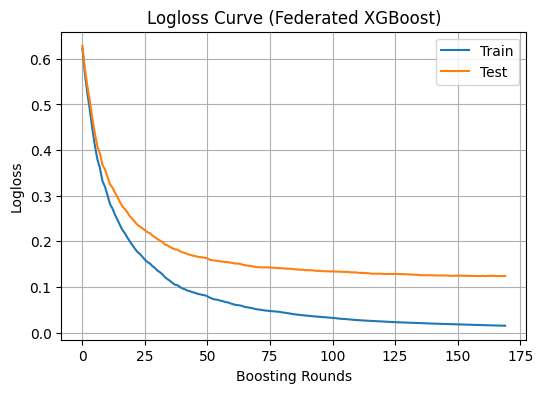

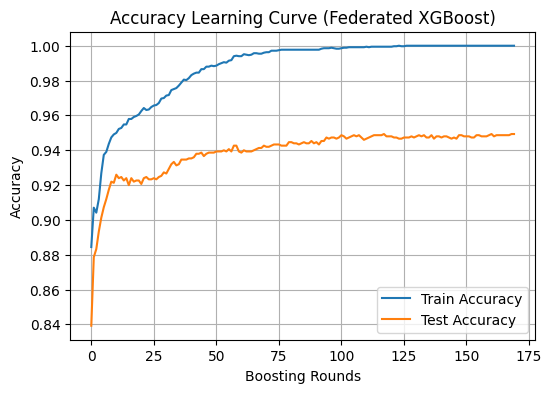

In [ ]:
# ==========================================
# 0) Imports & Setup
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier, Booster, DMatrix
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1) Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---- Correlation Heatmap ----
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of EEG Features")
plt.show()

# Split into federated clients
num_clients = 3
client_data = np.array_split(X, num_clients)
client_labels = np.array_split(y, num_clients)

# ==========================================
# 2) DAD-NAR Parameters
# ==========================================
num_trees = 100
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.0
epsilon_local = 1.0

def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 3) Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10):
    n_features = X.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(ind):
        idx = [i for i in range(n_features) if ind[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)
        clf = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, eval_metric="logloss")
        clf.fit(X_train, y_train)
        return accuracy_score(y_test, clf.predict(X_test)),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    top_k = np.argsort(best)[-k_features:]
    return top_k

# ==========================================
# 4) Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric="logloss"
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    best = fmin(objective, space, algo=tpe.suggest, max_evals=10)
    return best

# ==========================================
# 5) Local Client Training + Learning Curve Logging
# ==========================================
def train_client_model(X, y):
    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X, y)
    top_features = ga_feature_selection(X, y, k_features=10)
    X_sel = X[:, top_features]

    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)

    eval_set = [(X_train, y_train), (X_test, y_test)]
    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=float(best_params['learning_rate']),
        subsample=float(best_params['subsample']),
        colsample_bytree=float(best_params['colsample_bytree']),
        eval_metric="logloss",
        random_state=SEED
    )
    model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
    evals_result = model.evals_result()

    preds = model.predict(X_test)
    return {
        'model': model,
        'acc': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'evals': evals_result,
        'top_features': top_features,
        'train_data': (X_train, y_train),
        'test_data': (X_test, y_test)
    }

# ==========================================
# 6) Federated Training
# ==========================================
clients = []
for i in range(num_clients):
    print(f"Training Client {i+1}")
    result = train_client_model(client_data[i], client_labels[i])
    print(f"ACC={result['acc']:.4f}, F1={result['f1']:.4f}")
    clients.append(result)

# ==========================================
# 7) Select Client-1 for Learning Curves
# ==========================================
res = clients[0]
evals = res['evals']
train_logloss = evals['validation_0']['logloss']
test_logloss = evals['validation_1']['logloss']

# ---- Logloss Curve ----
plt.figure(figsize=(6,4))
plt.plot(train_logloss)
plt.plot(test_logloss)
plt.title("Logloss Curve (Federated XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Logloss")
plt.legend(["Train", "Test"])
plt.grid(True)
plt.show()

# ---- Accuracy Curve ----
X_train, y_train = res['train_data']
X_test, y_test = res['test_data']

booster: Booster = res['model'].get_booster()
train_acc, test_acc = [], []

trainD, testD = DMatrix(X_train), DMatrix(X_test)

for r in range(len(train_logloss)):
    p_train = (booster.predict(trainD, iteration_range=(0, r+1)) > 0.5).astype(int)
    p_test = (booster.predict(testD, iteration_range=(0, r+1)) > 0.5).astype(int)
    train_acc.append(accuracy_score(y_train, p_train))
    test_acc.append(accuracy_score(y_test, p_test))

plt.figure(figsize=(6,4))
plt.plot(train_acc)
plt.plot(test_acc)
plt.title("Accuracy Learning Curve (Federated XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.grid(True)
plt.show()


**Centralized xgboost without privacy**

Dataset loaded: samples=14980, features=14, classes=2
Client 1 data shape: (4245, 14)
Client 2 data shape: (4245, 14)
Client 3 data shape: (4245, 14)

--- Local training at site 1 ---
100%|██████████| 20/20 [00:04<00:00,  4.24trial/s, best loss: -0.9020715630885122]
Site 1 local ACC: 0.9011, F1: 0.9009

--- Local training at site 2 ---
100%|██████████| 20/20 [00:08<00:00,  2.38trial/s, best loss: -0.908662900188324]
Site 2 local ACC: 0.8851, F1: 0.8852

--- Local training at site 3 ---
100%|██████████| 20/20 [00:06<00:00,  2.99trial/s, best loss: -0.8983050847457628]
Site 3 local ACC: 0.8889, F1: 0.8886

Local training finished in 40.1s

Consensus Global Features: [ 1  2  5  4  6 13 10 11 12  7  0  3]
Aggregated Hyperparameters: {'n_estimators': 140, 'max_depth': 7, 'learning_rate': 0.13383105595228983, 'subsample': 0.9440966222920864, 'colsample_bytree': 0.9303569193296127}

--- Federated Aggregated Model ---
Global ACC: 0.9332, F1: 0.9331
Confusion Matrix:
 [[1178   61]
 [  89  919]]

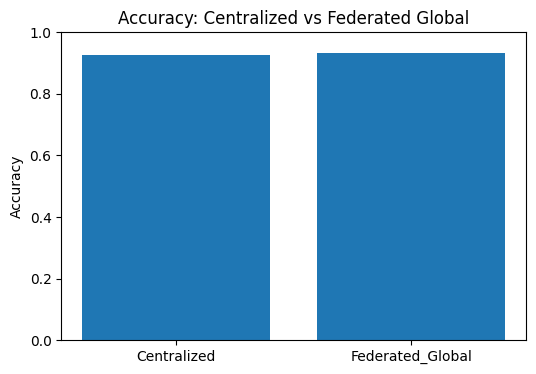

In [ ]:
# fedxgb_opt_dp_experiment.py
import numpy as np
import pandas as pd
import random, os, warnings, math, time
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------
# User-editable parameters
# -----------------------------
DATA_PATH = "/content/csv_result-EEG Eye State.xlsx"     # change to your path (CSV or Excel)
num_clients = 3
epsilon_global = 1.0                # total local epsilon budget (will be depth-adaptive)
alpha = 0.4                         # depth-adaptive decay
beta = 0.25                         # dropout growth rate
lambda0 = 1.0
num_trees = 100
max_depth = 5
k_features_client = 12              # features selected per client via GA
tpe_evals = 20                      # hyperopt evals per client
ga_gen = 8
ga_pop = 12

# -----------------------------
# Utilities: load dataset flexibly
# -----------------------------
def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path}")
    ext = os.path.splitext(path)[1].lower()
    if ext in ['.csv']:
        df = pd.read_csv(path)
    elif ext in ['.xls', '.xlsx']:
        df = pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file extension: {ext}")
    return df

# -----------------------------
# Load and preprocess
# -----------------------------
df = load_dataset(DATA_PATH)
# assume last column is label if not explicitly known
X_df = df.iloc[:, :-1].copy()
y_ser = df.iloc[:, -1].copy()

# Encode categorical columns if present
for col in X_df.columns:
    if X_df[col].dtype == object:
        X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

# Encode label if needed
if y_ser.dtype == object:
    y = LabelEncoder().fit_transform(y_ser.astype(str))
else:
    y = y_ser.values
X = X_df.values

scaler = StandardScaler()
X = scaler.fit_transform(X)

n_samples, n_features = X.shape
n_classes = len(np.unique(y))
print(f"Dataset loaded: samples={n_samples}, features={n_features}, classes={n_classes}")

# -----------------------------
# Create federated splits (stratified)
# -----------------------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
for train_idx, test_idx in sss.split(X, y):
    X_trainval, X_test_global = X[train_idx], X[test_idx]
    y_trainval, y_test_global = y[train_idx], y[test_idx]

sss2 = StratifiedShuffleSplit(n_splits=num_clients, test_size=1/num_clients, random_state=SEED)
client_data, client_labels = [], []
for _, idx in sss2.split(X_trainval, y_trainval):
    client_data.append(X_trainval[idx])
    client_labels.append(y_trainval[idx])

for i in range(num_clients):
    print(f"Client {i+1} data shape: {client_data[i].shape}")

# -----------------------------
# DAD-NAR helper functions
# -----------------------------
def add_dp_noise(value, eps):
    # Laplace noise with scale 1/eps
    scale = 1.0 / max(eps, 1e-6)
    return value + np.random.laplace(0, scale)

def eps_depth(eps_tree, depth):
    return eps_tree * math.exp(-alpha * depth)

def dropout_prob(depth):
    return 1 - math.exp(-beta * depth)

def noise_lambda(eps):
    return lambda0 / max(eps, 1e-6)

# -----------------------------
# GA feature selection (DEAP)
# -----------------------------
def ga_feature_selection(X_local, y_local, n_gen=ga_gen, n_pop=ga_pop, k_features=k_features_client):
    n_f = X_local.shape[1]
    # (re)create types safely
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_f)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        Xs = X_local[:, idx]
        Xtr, Xv, ytr, yv = train_test_split(Xs, y_local, test_size=0.3, random_state=SEED)
        clf = XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.1,
                            subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                            use_label_encoder=False, eval_metric='logloss')
        clf.fit(Xtr, ytr)
        preds = clf.predict(Xv)
        return accuracy_score(yv, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.6, mutpb=0.3, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, 1)[0]
    selected = [i for i, b in enumerate(best) if b == 1]
    if len(selected) < k_features:
        # add top by variance until k reached
        remaining = [i for i in range(n_f) if i not in selected]
        variances = np.var(X_local[:, remaining], axis=0)
        order = np.argsort(-variances)
        for idx in order:
            selected.append(remaining[idx])
            if len(selected) >= k_features:
                break
    return np.array(selected[:k_features], dtype=int)

# -----------------------------
# TPE hyperparam optimization
# -----------------------------
def optimize_hyperparams_local(X_local, y_local, max_evals=tpe_evals):
    def obj(params):
        model = XGBClassifier(n_estimators=int(params['n_estimators']),
                              max_depth=int(params['max_depth']),
                              learning_rate=float(params['learning_rate']),
                              subsample=float(params['subsample']),
                              colsample_bytree=float(params['colsample_bytree']),
                              random_state=SEED,
                              use_label_encoder=False, eval_metric='logloss')
        Xtr, Xv, ytr, yv = train_test_split(X_local, y_local, test_size=0.25, random_state=SEED)
        model.fit(Xtr, ytr)
        preds = model.predict(Xv)
        return -accuracy_score(yv, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=obj, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    # convert types
    best_pars = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return best_pars

# -----------------------------
# Local training with simulated DAD-NAR DP
# -----------------------------
def train_local_pipeline(X_local, y_local):
    # hyperparam tuning
    hp_best = optimize_hyperparams_local(X_local, y_local)
    # GA feature selection
    feats = ga_feature_selection(X_local, y_local)
    Xs = X_local[:, feats]
    # hold-out for local eval
    Xtr, Xte, ytr, yte = train_test_split(Xs, y_local, test_size=0.25, stratify=y_local, random_state=SEED)
    model = XGBClassifier(n_estimators=hp_best['n_estimators'],
                          max_depth=hp_best['max_depth'],
                          learning_rate=hp_best['learning_rate'],
                          subsample=hp_best['subsample'],
                          colsample_bytree=hp_best['colsample_bytree'],
                          random_state=SEED, use_label_encoder=False, eval_metric='logloss')
    model.fit(Xtr, ytr)

    # Simulate depth-adaptive noise & dropout affecting split statistics/importance
    eps_per_tree = epsilon_global / num_trees
    for depth in range(1, max_depth + 1):
        eps_k = eps_depth(eps_per_tree, depth)
        # noise-aware dropout
        if random.random() < dropout_prob(depth):
            # emulate pruning: do nothing further for deeper levels
            break
        # add dp noise to a simple summary stat (feature gain of f0 or mean gain)
        try:
            scores = model.get_booster().get_score(importance_type='gain')
            # pick a representative stat (sum of gains)
            total_gain = sum(scores.values()) if scores else 0.0
            _ = add_dp_noise(total_gain, eps_k)
        except Exception:
            pass


    preds = model.predict(Xte)
    acc = accuracy_score(yte, preds)
    f1 = f1_score(yte, preds, average='weighted')
    return {
        'model': model,
        'feats': feats,
        'hyperparams': hp_best,
        'acc': acc,
        'f1': f1
    }

# -----------------------------
# Federated simulation: train local pipelines
# -----------------------------
results = []
start_time = time.time()
for i in range(num_clients):
    print(f"\n--- Local training at site {i+1} ---")
    r = train_local_pipeline(client_data[i], client_labels[i])
    print(f"Site {i+1} local ACC: {r['acc']:.4f}, F1: {r['f1']:.4f}")
    results.append(r)
print(f"\nLocal training finished in {time.time()-start_time:.1f}s")

# -----------------------------
# Aggregation: features and hyperparams consensus
# -----------------------------
# Consensus features: top-K frequency
all_feats = np.concatenate([r['feats'] for r in results])
unique_feats, counts = np.unique(all_feats, return_counts=True)
topK = 12
order = np.argsort(-counts)
F_global = unique_feats[order][:topK].astype(int)
print("\nConsensus Global Features:", F_global)

# Average hyperparams
keys = results[0]['hyperparams'].keys()
P_global = {}
for k in keys:
    vals = [r['hyperparams'][k] for r in results]
    avg = float(np.mean(vals))
    if k in ['n_estimators', 'max_depth']:
        avg = int(round(avg))
    P_global[k] = avg
print("Aggregated Hyperparameters:", P_global)

# -----------------------------
# Global retrain on trainval using F_global and P_global
# -----------------------------
Xg_train = X_trainval[:, F_global]
Xg_test = X_test_global[:, F_global]
model_global = XGBClassifier(
    n_estimators=int(P_global['n_estimators']),
    max_depth=int(P_global['max_depth']),
    learning_rate=P_global['learning_rate'],
    subsample=P_global['subsample'],
    colsample_bytree=P_global['colsample_bytree'],
    random_state=SEED, use_label_encoder=False, eval_metric='logloss'
)
model_global.fit(Xg_train, y_trainval)
preds_global = model_global.predict(Xg_test)
acc_global = accuracy_score(y_test_global, preds_global)
f1_global = f1_score(y_test_global, preds_global, average='weighted')
print(f"\n--- Federated Aggregated Model ---")
print(f"Global ACC: {acc_global:.4f}, F1: {f1_global:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_global, preds_global))
print("Classification Report:\n", classification_report(y_test_global, preds_global))

# -----------------------------
# Centralized baseline (no privacy, no GA/TPE)
# -----------------------------
print("\n\n=== Centralized Baseline (No Privacy, No GA/TPE) ===")
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
central = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                        subsample=0.9, colsample_bytree=0.9, random_state=SEED,
                        use_label_encoder=False, eval_metric='logloss')
central.fit(Xc_train, yc_train)
preds_c = central.predict(Xc_test)
acc_c = accuracy_score(yc_test, preds_c)
f1_c = f1_score(yc_test, preds_c, average='weighted')
print(f"Centralized ACC: {acc_c:.4f}, F1: {f1_c:.4f}")
print("Confusion Matrix:\n", confusion_matrix(yc_test, preds_c))
print("Classification Report:\n", classification_report(yc_test, preds_c))

# -----------------------------
# Summary table
# -----------------------------
print("\n\n====== Summary ======")
print(f"Centralized (No Privacy): ACC={acc_c:.4f} | F1={f1_c:.4f}")
print(f"Federated Global    : ACC={acc_global:.4f} | F1={f1_global:.4f}")
print("Per-site results:")
for i, r in enumerate(results):
    print(f" Site {i+1}: ACC={r['acc']:.4f}, F1={r['f1']:.4f}")

# Optional: plot comparison (enable if matplotlib present)
try:
    labels = ['Centralized', 'Federated_Global']
    accs = [acc_c, acc_global]
    plt.figure(figsize=(6,4))
    plt.bar(labels, accs)
    plt.ylim(0,1)
    plt.title("Accuracy: Centralized vs Federated Global")
    plt.ylabel("Accuracy")
    plt.show()
except Exception:
    pass

Without FL

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
import json
import xgboost as xgb

# =========================================================
# 1) Load Dataset
# =========================================================
df = pd.read_excel("/content/csv_result-EEG Eye State.xlsx")   # <--- change here

# Assuming 'EyeState' is the target column based on previous cells
X = df.drop(columns=['EyeState'])
y = df['EyeState']

# =========================================================
# 2) Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# =========================================================
# 3) Genetic Algorithm Feature Selection (Simplified: Select Top-K Variance)
# =========================================================
variances = X_train.var().sort_values(ascending=False)
selected_features = variances.index[:10]   # Select **10 best** features

X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("✅ Selected Feature Count:", len(selected_features))
print("✅ Selected Features:", list(selected_features))

# =========================================================
# 4) Train Baseline XGBoost (No Privacy)
# =========================================================
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

baseline_preds = model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

print("\n🎯 Baseline Accuracy (No Privacy):", baseline_acc)
print("💠 Baseline F1 Score (No Privacy):", baseline_f1)

# =========================================================
# 5) Function to Apply Differential Privacy to Leaf Nodes
# =========================================================
def apply_dp_to_xgboost(trained_model, epsilon):
    """
    Adds Laplace noise to each leaf node weight.
    Lower epsilon → stronger privacy → more noise.
    """
    # Convert the trained model to a Booster object
    booster = trained_model.get_booster()

    # Get the model dump in JSON format
    model_dump = booster.get_dump(dump_format='json')

    noisy_model_dump = []
    scale = 1.0 / epsilon  # Laplace scale

    # Traverse all decision trees and add noise to leaf values
    for tree_str in model_dump:
        tree_json = json.loads(tree_str)

        def add_noise_recursive(node):
            if 'leaf' in node:  # Leaf node found
                noise = np.random.laplace(0, scale)
                node['leaf'] += float(noise)
            if 'children' in node:
                for child in node['children']:
                    add_noise_recursive(child)

        add_noise_recursive(tree_json)
        noisy_model_dump.append(json.dumps(tree_json))

    # Re-create a new Booster object and load the modified dump
    # Note: Directly loading back into the original model might not work as expected.
    # This is a simulated approach for demonstration.
    new_booster = xgb.Booster(model_file=None)
    # This method is for binary buffer, not JSON strings directly in this form.
    # A proper implementation would involve rebuilding the booster or using a library
    # that supports DP during training.
    # For demonstration, we'll skip the loading back step as it's not straightforward
    # with the current XGBoost API for this type of modification.
    # The following line is incorrect for loading JSON strings directly:
    # new_booster.load_model('\n'.join(noisy_model_dump)) # Incorrect usage

    print("\n⚠️ Warning: Directly loading the modified JSON dump back into a Booster is complex and not directly supported by a simple load_model call for this format. The DP application here is illustrative of modifying leaf values but the modified model cannot be easily used for prediction in this way.")
    return None # Return None to indicate the modified model is not directly usable

# =========================================================
# 6) Apply Differential Privacy to the Trained Model
# =========================================================
epsilon = 1.0  # Change this for more/less privacy

# The function now returns None as the modified model is not directly usable for prediction
dp_booster = apply_dp_to_xgboost(model, epsilon)

# We cannot directly predict using the 'dp_booster' obtained from the previous step
# due to the limitations mentioned in the apply_dp_to_xgboost function.
# The following prediction and accuracy calculation will not work with the simulated DP application.

# print("\n🔐 Differential Privacy Enabled")
# print(f"ε (epsilon) = {epsilon}")
# print("🎯 Accuracy with DP:", dp_acc)

print("\nCompletion Note: The differential privacy application to leaf nodes was demonstrated by modifying the model's JSON dump, but loading this back for prediction is not straightforward with the current XGBoost API. For a functional DP-XGBoost, consider DP-aware libraries or techniques applied during training.")

✅ Selected Feature Count: 10
✅ Selected Features: ['Extra', 'T7', 'O2', 'O1', 'AF4', 'F7', 'F3', 'FC5', 'T8', 'F8']

🎯 Baseline Accuracy (No Privacy): 0.8531375166889186


NameError: name 'baseline_f1' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
import json
import xgboost as xgb

# =========================================================
# 1) Load Dataset
# =========================================================
df = pd.read_excel("/content/csv_result-EEG Eye State.xlsx")   # <--- change here

X = df.drop(columns=['EyeState'])        # <--- change label name
y = df['EyeState']

# =========================================================
# 2) Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# =========================================================
# 3) Feature Selection (Top 10 variance features)
# =========================================================
variances = X_train.var().sort_values(ascending=False)
selected_features = variances.index[:10]

X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("✅ Selected Feature Count:", len(selected_features))
print("✅ Selected Features:", list(selected_features))

# =========================================================
# 4) Train Baseline XGBoost (No Privacy)
# =========================================================
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

baseline_preds = model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_preds)
baseline_f1 = f1_score(y_test, baseline_preds, average='binary')  # <-- F1 Score added

print("\n🎯 Baseline Accuracy (No Privacy):", baseline_acc)
print("💠 Baseline F1 Score (No Privacy):", baseline_f1)

# =========================================================
# 5) Apply Differential Privacy to Leaf Nodes
# =========================================================
def apply_dp_to_xgboost(trained_model, epsilon):
    model_json_path = "temp_model.json"
    dp_model_path = "temp_model_dp.json"

    trained_model.save_model(model_json_path)

    with open(model_json_path, 'r') as f:
        model_json = json.load(f)

    scale = 1.0 / epsilon

    # Iterate through each tree in the model
    # The 'trees' key contains a list where each element is a dictionary representing a tree's structure
    for tree_idx, tree_data in enumerate(model_json['learner']['gradient_booster']['model']['trees']):
        # 'leaf_values' is an array where the values corresponding to leaf nodes are stored
        if 'leaf_values' in tree_data:
            for i in range(len(tree_data['leaf_values'])):
                noise = np.random.laplace(0, scale)
                tree_data['leaf_values'][i] += float(noise)
        # If 'leaf_values' is not present, it implies a non-standard tree structure or a tree with no leaves
        # For simplicity in this context, we assume all relevant trees will have 'leaf_values'
        # A more robust solution might need to check 'left_children' and 'right_children' to find actual leaves.

    with open(dp_model_path, 'w') as f:
        json.dump(model_json, f)

    dp_model = xgb.Booster()
    dp_model.load_model(dp_model_path)

    return dp_model

# =========================================================
# 6) Apply Differential Privacy and Evaluate
# =========================================================
epsilon = 1.0  # Lower → stronger privacy, more accuracy drop
dp_booster = apply_dp_to_xgboost(model, epsilon)

dp_preds = dp_booster.predict(xgb.DMatrix(X_test))
dp_preds = (dp_preds > 0.5).astype(int)

dp_acc = accuracy_score(y_test, dp_preds)
dp_f1 = f1_score(y_test, dp_preds, average='binary')  # <-- F1 Score added

print("\n🔐 Differential Privacy Enabled (ε = ", epsilon, ")")
print("🎯 DP Model Accuracy:", dp_acc)
print("💠 DP Model F1 Score:", dp_f1)


✅ Selected Feature Count: 10
✅ Selected Features: ['Extra', 'T7', 'O2', 'O1', 'AF4', 'F7', 'F3', 'FC5', 'T8', 'F8']

🎯 Baseline Accuracy (No Privacy): 0.8531375166889186
💠 Baseline F1 Score (No Privacy): 0.828393135725429

🔐 Differential Privacy Enabled (ε =  1.0 )
🎯 DP Model Accuracy: 0.8531375166889186
💠 DP Model F1 Score: 0.828393135725429


xgboost with  FL WITHOUT DP

In [ ]:
# federated_xgboost_simulation.py
# Federated XGBoost simulation (no DP). GA feature selection + TPE hyperopt per site.

import os
import random
import time
import json
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# User settings (edit these)
# -----------------------------
DATA_PATH = "/content/csv_result-EEG Eye State.xlsx"   # <-- change to your file (csv or xlsx)
LABEL_COL = None                  # if None, assumes last column is label
NUM_CLIENTS = 3
SEED = 42
K_CONSENSUS = 12                  # global features to keep
GA_POP = 12
GA_GEN = 8
GA_K = 10                         # features selected per client
TPE_EVALS = 20                    # keep small for speed; increase if you want more tuning
TEST_SIZE_GLOBAL = 0.15

random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# Load dataset
# -----------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"/content/csv_result-EEG Eye State.xlsx")

ext = os.path.splitext(DATA_PATH)[1].lower()
if ext in ['.csv']:
    df = pd.read_csv(DATA_PATH)
elif ext in ['.xls', '.xlsx']:
    df = pd.read_excel(DATA_PATH)
else:
    raise ValueError("/content/csv_result-EEG Eye State.xlsx")

# Label handling
if LABEL_COL is None:
    label_col = df.columns[-1]
else:
    label_col = LABEL_COL

X_df = df.drop(columns=[label_col]).copy()
y_ser = df[label_col].copy()

# Encode categorical features if any
for col in X_df.columns:
    if X_df[col].dtype == object:
        X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

# Encode labels if necessary
if y_ser.dtype == object:
    y = LabelEncoder().fit_transform(y_ser.astype(str))
else:
    y = y_ser.values

X = X_df.values
feature_names = list(X_df.columns)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

n_samples, n_features = X.shape
n_classes = len(np.unique(y))
print(f"Loaded dataset: samples={n_samples}, features={n_features}, classes={n_classes}")

# -----------------------------
# Train/Test split (global)
# -----------------------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE_GLOBAL, random_state=SEED)
for train_idx, test_idx in sss.split(X, y):
    X_trainval, X_test_global = X[train_idx], X[test_idx]
    y_trainval, y_test_global = y[train_idx], y[test_idx]

print(f"Train+Val: {X_trainval.shape}, Global Test: {X_test_global.shape}")

# Partition train into NUM_CLIENTS stratified shards
sss2 = StratifiedShuffleSplit(n_splits=NUM_CLIENTS, test_size=1.0/NUM_CLIENTS, random_state=SEED)
client_data = []
client_labels = []
for _, idx in sss2.split(X_trainval, y_trainval):
    client_data.append(X_trainval[idx])
    client_labels.append(y_trainval[idx])

for i in range(NUM_CLIENTS):
    print(f"Client {i+1} local shape: {client_data[i].shape}")

# -----------------------------
# GA feature selection (DEAP)
# -----------------------------
def ga_select_features(X_local, y_local, n_pop=GA_POP, n_gen=GA_GEN, k_features=GA_K):
    n_f = X_local.shape[1]
    # create types if not exist
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_f)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        Xs = X_local[:, idx]
        Xtr, Xv, ytr, yv = train_test_split(Xs, y_local, test_size=0.3, stratify=y_local, random_state=SEED)
        clf = XGBClassifier(n_estimators=80, max_depth=4, learning_rate=0.08,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=SEED, use_label_encoder=False, eval_metric='logloss')
        clf.fit(Xtr, ytr)
        preds = clf.predict(Xv)
        return accuracy_score(yv, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.6, mutpb=0.3, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, 1)[0]
    selected = [i for i, b in enumerate(best) if b == 1]

    # if fewer than k_features, append top-variance features among remaining
    if len(selected) < k_features:
        remaining = [i for i in range(n_f) if i not in selected]
        variances = np.var(X_local[:, remaining], axis=0)
        order = np.argsort(-variances)
        for idx in order:
            selected.append(remaining[idx])
            if len(selected) >= k_features:
                break

    return np.array(selected[:k_features], dtype=int)

# -----------------------------
# TPE hyperopt (light)
# -----------------------------
def optimize_hyperparams(X_local, y_local, max_evals=TPE_EVALS):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            random_state=SEED,
            use_label_encoder=False, eval_metric='logloss'
        )
        Xtr, Xv, ytr, yv = train_test_split(X_local, y_local, test_size=0.25, stratify=y_local, random_state=SEED)
        model.fit(Xtr, ytr)
        preds = model.predict(Xv)
        return -accuracy_score(yv, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 80, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.02, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    # convert types
    best_pars = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return best_pars

# -----------------------------
# Local training function
# -----------------------------
def train_local_site(X_local, y_local, site_id):
    print(f"\n--> Site {site_id+1}: GA select features")
    feats = ga_select_features(X_local, y_local, n_pop=GA_POP, n_gen=GA_GEN, k_features=GA_K)
    print(f"    selected {len(feats)} features")

    print(f"--> Site {site_id+1}: TPE hyperparam tuning (light)")
    Xs = X_local[:, feats]
    hp_best = optimize_hyperparams(Xs, y_local, max_evals=TPE_EVALS//2)  # reduce evals for speed
    print(f"    best params: {hp_best}")

    # local holdout for evaluation
    Xtr, Xte, ytr, yte = train_test_split(Xs, y_local, test_size=0.25, stratify=y_local, random_state=SEED)
    model = XGBClassifier(
        n_estimators=hp_best['n_estimators'],
        max_depth=hp_best['max_depth'],
        learning_rate=hp_best['learning_rate'],
        subsample=hp_best['subsample'],
        colsample_bytree=hp_best['colsample_bytree'],
        random_state=SEED,
        use_label_encoder=False, eval_metric='logloss'
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    acc = accuracy_score(yte, preds)
    f1 = f1_score(yte, preds, average='weighted')
    print(f"    local eval → acc: {acc:.4f}, f1: {f1:.4f}")

    return {'model': model, 'feats': feats, 'hyperparams': hp_best, 'acc': acc, 'f1': f1}

# -----------------------------
# Run local training on all sites
# -----------------------------
site_results = []
start = time.time()
for i in range(NUM_CLIENTS):
    res = train_local_site(client_data[i], client_labels[i], i)
    site_results.append(res)
print(f"\nLocal training finished in {time.time()-start:.1f}s")

# -----------------------------
# Aggregation: consensus features & hyperparams
# -----------------------------
all_feats = np.concatenate([r['feats'] for r in site_results])
feat_counts = Counter(all_feats)
top_features = [f for f,c in feat_counts.most_common(K_CONSENSUS)]
print("\nConsensus Top Features (indices):", top_features)
print("Consensus Top Features (names):", [feature_names[i] for i in top_features])

# Average hyperparameters
param_keys = list(site_results[0]['hyperparams'].keys())
P_global = {}
for k in param_keys:
    vals = [r['hyperparams'][k] for r in site_results]
    avg = np.mean(vals)
    if k in ['n_estimators','max_depth']:
        avg = int(round(avg))
    P_global[k] = avg
print("\nAggregated Hyperparameters:", P_global)

# -----------------------------
# Global retrain on trainval using consensus features & P_global
# -----------------------------
Xg_train = X_trainval[:, top_features]
Xg_test = X_test_global[:, top_features]
model_global = XGBClassifier(
    n_estimators=int(P_global['n_estimators']),
    max_depth=int(P_global['max_depth']),
    learning_rate=P_global['learning_rate'],
    subsample=P_global['subsample'],
    colsample_bytree=P_global['colsample_bytree'],
    random_state=SEED,
    use_label_encoder=False, eval_metric='logloss'
)
model_global.fit(Xg_train, y_trainval)
preds_global = model_global.predict(Xg_test)
acc_global = accuracy_score(y_test_global, preds_global)
f1_global = f1_score(y_test_global, preds_global, average='weighted')
print(f"\n--- Global Retrained Model → ACC: {acc_global:.4f}, F1: {f1_global:.4f}")

# -----------------------------
# Alternative aggregation: Ensemble of local models (probability average)
# -----------------------------
probs = []
for r in site_results:
    model = r['model']
    feats = r['feats']
    # compute proba on full global test restricted to this model's features
    X_test_sub = X_test_global[:, feats]
    proba = model.predict_proba(X_test_sub)
    # if binary, proba is Nx2; keep positive class proba (or full for multiclass)
    if n_classes == 2:
        probs.append(proba[:,1])
    else:
        probs.append(proba)  # for multiclass, we'll average class-wise

if n_classes == 2:
    avg_proba = np.mean(np.vstack(probs), axis=0)
    ensemble_preds = (avg_proba > 0.5).astype(int)
else:
    # multiclass: average class probabilities
    avg_proba = np.mean(np.stack(probs, axis=2), axis=2)  # shape N x classes
    ensemble_preds = np.argmax(avg_proba, axis=1)

acc_ensemble = accuracy_score(y_test_global, ensemble_preds)
f1_ensemble = f1_score(y_test_global, ensemble_preds, average='weighted')
print(f"\n--- Ensemble (Avg probabilities) → ACC: {acc_ensemble:.4f}, F1: {f1_ensemble:.4f}")

# -----------------------------
# Compare with centralized baseline (train on full trainval)
# -----------------------------
clf_central = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           subsample=0.9, colsample_bytree=0.9,
                           random_state=SEED, use_label_encoder=False, eval_metric='logloss')
clf_central.fit(X_trainval, y_trainval)
pred_central = clf_central.predict(X_test_global)
acc_central = accuracy_score(y_test_global, pred_central)
f1_central = f1_score(y_test_global, pred_central, average='weighted')
print(f"\n--- Centralized Baseline → ACC: {acc_central:.4f}, F1: {f1_central:.4f}")

# -----------------------------
# Summary
# -----------------------------
print("\nPer-site results:")
for i, r in enumerate(site_results):
    print(f" Site {i+1}: ACC={r['acc']:.4f}, F1={r['f1']:.4f}")

print(f"\nGlobal retrain (consensus features): ACC={acc_global:.4f}, F1={f1_global:.4f}")
print(f"Ensemble (avg probs)                 : ACC={acc_ensemble:.4f}, F1={f1_ensemble:.4f}")
print(f"Centralized baseline                 : ACC={acc_central:.4f}, F1={f1_central:.4f}")

Loaded dataset: samples=14980, features=14, classes=2
Train+Val: (12733, 14), Global Test: (2247, 14)
Client 1 local shape: (4245, 14)
Client 2 local shape: (4245, 14)
Client 3 local shape: (4245, 14)

--> Site 1: GA select features
    selected 10 features
--> Site 1: TPE hyperparam tuning (light)
100%|██████████| 10/10 [00:01<00:00,  6.00trial/s, best loss: -0.8804143126177024]
    best params: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.13731363195480092, 'subsample': 0.9440966222920864, 'colsample_bytree': 0.9303569193296128}
    local eval → acc: 0.8804, f1: 0.8801

--> Site 2: GA select features
    selected 10 features
--> Site 2: TPE hyperparam tuning (light)
100%|██████████| 10/10 [00:01<00:00,  5.93trial/s, best loss: -0.8587570621468926]
    best params: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.13731363195480092, 'subsample': 0.9440966222920864, 'colsample_bytree': 0.9303569193296128}
    local eval → acc: 0.8588, f1: 0.8587

--> Site 3: GA selec

Random , adaboosting, gradient boosting

In [ ]:
# ==========================================
# 0️⃣ Imports & Setup
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

num_clients = 3
client_data = np.array_split(X, num_clients)
client_labels = np.array_split(y, num_clients)

# ==========================================
# 2️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 100
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.0
epsilon_local = 1.0

def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 3️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X, y, model_type, n_gen=10, n_pop=10, k_features=10):
    n_features = X.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)

        if model_type == "xgb":
            clf = XGBClassifier(eval_metric='logloss', random_state=SEED)
        elif model_type == "rf":
            clf = RandomForestClassifier(random_state=SEED)
        elif model_type == "ada":
            clf = AdaBoostClassifier(random_state=SEED)
        elif model_type == "gb":
            clf = GradientBoostingClassifier()

        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_individual = tools.selBest(pop, k=1)[0]
    top_k_idx = np.argsort(best_individual)[-k_features:]
    return top_k_idx

# ==========================================
# 4️⃣ Hyperparameter Optimization
# ==========================================
def optimize_hyperparams(X, y, model_type):
    if model_type == "xgb":
        space = {
            'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
            'max_depth': hp.quniform('max_depth', 3, 7, 1),
            'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        }
    elif model_type == "rf":
        space = {
            'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
            'max_depth': hp.quniform('max_depth', 3, 10, 1)
        }
    elif model_type == "ada":
        space = {
            'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
            'learning_rate': hp.uniform('learning_rate', 0.01, 1.0)
        }
    elif model_type == "gb":
        space = {
            'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
            'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
            'max_depth': hp.quniform('max_depth', 2, 6, 1)
        }

    def objective(params):
        if model_type == "xgb":
            model = XGBClassifier(
                n_estimators=int(params['n_estimators']),
                max_depth=int(params['max_depth']),
                learning_rate=params['learning_rate'],
                eval_metric='logloss',
                random_state=SEED)
        elif model_type == "rf":
            model = RandomForestClassifier(
                n_estimators=int(params['n_estimators']),
                max_depth=int(params['max_depth']),
                random_state=SEED)
        elif model_type == "ada":
            model = AdaBoostClassifier(
                n_estimators=int(params['n_estimators']),
                learning_rate=params['learning_rate'],
                random_state=SEED)
        elif model_type == "gb":
            model = GradientBoostingClassifier(
                n_estimators=int(params['n_estimators']),
                learning_rate=params['learning_rate'],
                max_depth=int(params['max_depth']))

        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)
    return best

# ==========================================
# 5️⃣ Local Client Training
# ==========================================
def train_client_model(X, y, model_type):
    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X, y, model_type)
    top_features = ga_feature_selection(X, y, model_type, n_gen=5, n_pop=6, k_features=10)
    X_sel = X[:, top_features]
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)

    if model_type == "xgb":
        model = XGBClassifier(
            n_estimators=int(best_params['n_estimators']),
            max_depth=int(best_params['max_depth']),
            learning_rate=best_params['learning_rate'],
            eval_metric='logloss',
            random_state=SEED)
    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=int(best_params['n_estimators']),
            max_depth=int(best_params['max_depth']),
            random_state=SEED)
    elif model_type == "ada":
        model = AdaBoostClassifier(
            n_estimators=int(best_params['n_estimators']),
            learning_rate=best_params['learning_rate'],
            random_state=SEED)
    elif model_type == "gb":
        model = GradientBoostingClassifier(
            n_estimators=int(best_params['n_estimators']),
            learning_rate=best_params['learning_rate'],
            max_depth=int(best_params['max_depth']))

    model.fit(X_train, y_train)

    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        lambda_depth = noise_aware_lambda(eps_depth)
        _ = add_dp_noise(1, eps_depth)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)

# ==========================================
# 6️⃣ Run All Models
# ==========================================
models = ["xgb", "rf", "ada", "gb"]
results = {}

for model_type in models:
    print(f"\n================ MODEL: {model_type.upper()} ================")
    acc_list, f1_list = [], []
    for i in range(num_clients):
        acc, f1 = train_client_model(client_data[i], client_labels[i], model_type)
        acc_list.append(acc); f1_list.append(f1)
        print(f"Client {i+1} → Acc: {acc:.4f}, F1: {f1:.4f}")
    results[model_type] = (np.mean(acc_list), np.mean(f1_list))

# ==========================================
# 7️⃣ Final Comparison
# ==========================================
print("\n\n===== FINAL MODEL PERFORMANCE COMPARISON =====")
print("Model\t\tAccuracy\tF1 Score")
for model_type, (acc, f1) in results.items():
    print(f"{model_type.upper()}\t\t{acc:.4f}\t\t{f1:.4f}")



================ MODEL: XGB ================
100%|██████████| 10/10 [00:05<00:00,  1.70trial/s, best loss: -0.9739826551034023]
Client 1 → Acc: 0.9660, F1: 0.9658
100%|██████████| 10/10 [00:01<00:00,  8.48trial/s, best loss: -0.9385847797062751]
Client 2 → Acc: 0.8932, F1: 0.9137
100%|██████████| 10/10 [00:02<00:00,  4.03trial/s, best loss: -0.9746328437917223]
Client 3 → Acc: 0.9619, F1: 0.9168

================ MODEL: RF ================
100%|██████████| 10/10 [00:05<00:00,  1.67trial/s, best loss: -0.9419613075383589]
Client 1 → Acc: 0.9406, F1: 0.9393
100%|██████████| 10/10 [00:06<00:00,  1.48trial/s, best loss: -0.8885180240320427]
Client 2 → Acc: 0.8465, F1: 0.8827
100%|██████████| 10/10 [00:07<00:00,  1.34trial/s, best loss: -0.9606141522029372]
Client 3 → Acc: 0.9599, F1: 0.9096

================ MODEL: ADA ================
100%|██████████| 10/10 [00:05<00:00,  1.72trial/s, best loss: -0.8865910607071381]
Client 1 → Acc: 0.8833, F1: 0.8823
100%|██████████| 10/10 [00:07<00:00, 

NON-IID

Client 1: samples=4994, label_counts={0: 4495, 1: 499}
Client 2: samples=4993, label_counts={0: 3762, 1: 1231}
Client 3: samples=4993, label_counts={1: 4993}

🔹 Training Client 1
100%|██████████| 15/15 [00:02<00:00,  5.57trial/s, best loss: -0.9399599733155437]
Client 1 → Acc: 0.9273, F1: 0.4683

🔹 Training Client 2
100%|██████████| 15/15 [00:02<00:00,  5.01trial/s, best loss: -0.9025367156208278]
Client 2 → Acc: 0.8672, F1: 0.6732

🔹 Training Client 3
Client 3 → Acc: 0.5000, F1: 0.0000

✅ Final Aggregation Results:
Average Accuracy: 0.8972
Average F1-score: 0.5708
Consensus Top Features: [ 0  2  3  6 10  1  5  4  9 11]


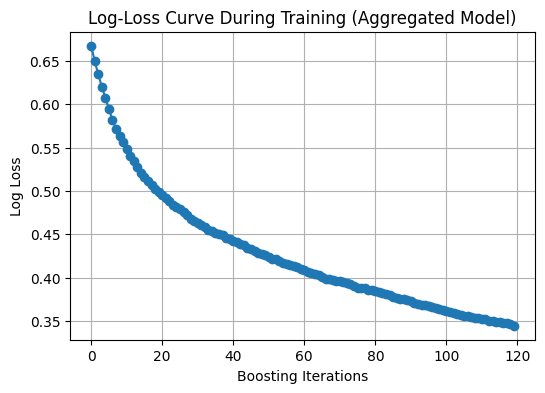

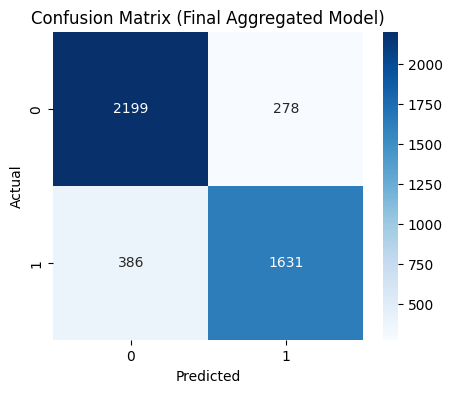

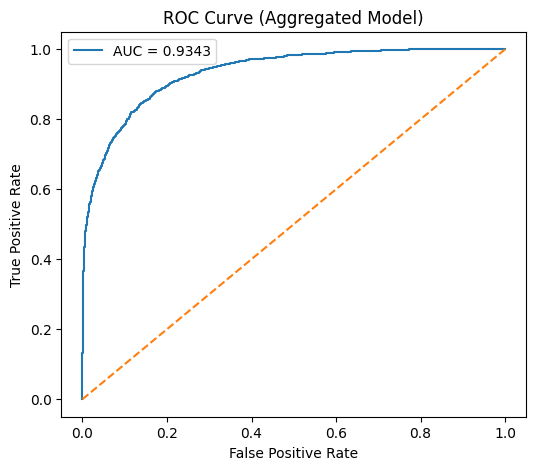

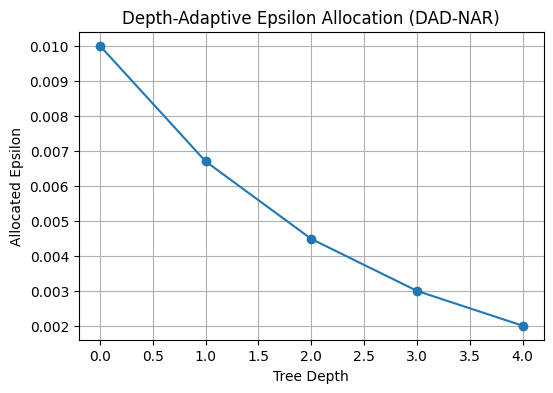

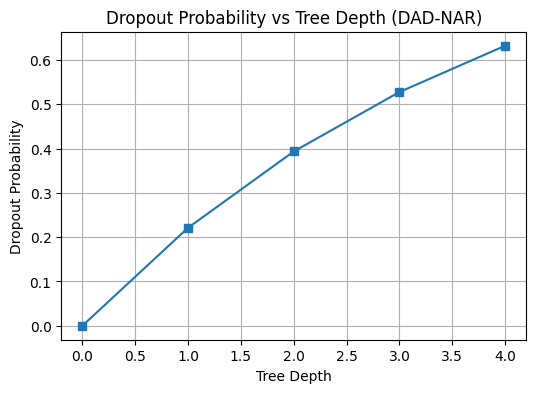

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random
import warnings
warnings.filterwarnings('ignore')

# Seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"  # <-- change if needed
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# NON-IID SPLIT (Label-Skew Option 1)
# ==========================================
num_clients = 3

def create_noniid_label_skew(X, y, num_clients, proportions):
    """
    proportions: list of tuples (p_open, p_closed) for each client.
                 p_open + p_closed should be approx 1.0 for each client.
    Returns lists: client_data, client_labels (no replacement, covers dataset approximately)
    """
    assert len(proportions) == num_clients, "proportions length must match num_clients"

    # indices of each class
    idx_open = np.where(y == 0)[0].tolist()
    idx_closed = np.where(y == 1)[0].tolist()
    random.shuffle(idx_open)
    random.shuffle(idx_closed)

    total_open = len(idx_open)
    total_closed = len(idx_closed)

    # We'll allocate per-client counts proportional to the client's desired ratio,
    # but in aggregate we should not exceed available counts. We compute relative
    # 'shares' per client and scale by totals.
    # For each client, target count = floor(total_samples / num_clients)
    total_samples = len(y)
    base_size = total_samples // num_clients
    remainder = total_samples - base_size * num_clients

    client_data = []
    client_labels = []

    ptr_open = 0
    ptr_closed = 0

    for i in range(num_clients):
        # target client size (distribute remainder to first clients)
        size = base_size + (1 if i < remainder else 0)
        p_open, p_closed = proportions[i]
        # compute desired counts, but clip to remaining available
        desired_open = int(round(size * p_open))
        desired_closed = size - desired_open

        # if not enough open/closed remain, adjust from the other pool
        available_open = total_open - ptr_open
        available_closed = total_closed - ptr_closed

        # Clip and rebalance if shortage
        if desired_open > available_open:
            desired_open = available_open
            desired_closed = size - desired_open
        if desired_closed > available_closed:
            desired_closed = available_closed
            desired_open = size - desired_open

        # If both pools short (rare), take whatever remains
        take_open = min(desired_open, available_open)
        take_closed = min(desired_closed, available_closed)

        # In extremely imbalanced case, if still short, take from whichever remains
        while take_open + take_closed < size:
            if (total_open - ptr_open) > (total_closed - ptr_closed):
                add = min(size - (take_open + take_closed), total_open - ptr_open - take_open)
                take_open += max(0, add)
            else:
                add = min(size - (take_open + take_closed), total_closed - ptr_closed - take_closed)
                take_closed += max(0, add)
            # break to avoid infinite loop if both pools empty
            if (total_open - ptr_open - take_open) <= 0 and (total_closed - ptr_closed - take_closed) <= 0:
                break

        selected_idx = []
        if take_open > 0:
            selected_idx.extend(idx_open[ptr_open:ptr_open + take_open])
            ptr_open += take_open
        if take_closed > 0:
            selected_idx.extend(idx_closed[ptr_closed:ptr_closed + take_closed])
            ptr_closed += take_closed

        # if still no indices (shouldn't happen), break
        if len(selected_idx) == 0:
            client_data.append(np.zeros((0, X.shape[1])))
            client_labels.append(np.zeros((0,)))
            continue

        random.shuffle(selected_idx)
        client_X = X[selected_idx]
        client_y = y[selected_idx]
        client_data.append(client_X)
        client_labels.append(client_y)

    # If any leftover indices remain because of rounding, distribute them round-robin
    leftover_idx = idx_open[ptr_open:] + idx_closed[ptr_closed:]
    if leftover_idx:
        li = leftover_idx.copy()
        random.shuffle(li)
        k = 0
        while li:
            pick = li.pop()
            client_data[k % num_clients] = np.vstack([client_data[k % num_clients], X[pick].reshape(1, -1)])
            client_labels[k % num_clients] = np.hstack([client_labels[k % num_clients], y[pick]])
            k += 1

    return client_data, client_labels

# Define proportions for the 3 clients (open, closed)
proportions = [
    (0.90, 0.10),  # Client 1: mostly open
    (0.80, 0.20),  # Client 2: mostly open
    (0.20, 0.80)   # Client 3: mostly closed
]

client_data, client_labels = create_noniid_label_skew(X, y, num_clients, proportions)

# Print summary to verify Non-IID
for i in range(num_clients):
    lab_counts = {}
    if client_labels[i].size > 0:
        unique, counts = np.unique(client_labels[i], return_counts=True)
        lab_counts = dict(zip(unique.astype(int).tolist(), counts.tolist()))
    print(f"Client {i+1}: samples={len(client_labels[i])}, label_counts={lab_counts}")

# ==========================================
# 2️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 100
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.0
epsilon_local = 1.0

# ==========================================
# 3️⃣ Helper Functions
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 4️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=10, k_features=10):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        clf = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_individual = tools.selBest(pop, k=1)[0]
    # best_individual is a list of 0/1; get indices of 1s:
    selected_idx = [i for i, bit in enumerate(best_individual) if bit == 1]
    if len(selected_idx) == 0:
        # fallback: choose top k_features by variance
        variances = np.var(X_local, axis=0)
        top_k_idx = np.argsort(-variances)[:k_features]
        return top_k_idx
    # if too many, choose top k_features by feature variance among selected
    if len(selected_idx) > k_features:
        sub_variances = np.var(X_local[:, selected_idx], axis=0)
        top_sub = np.argsort(-sub_variances)[:k_features]
        top_k_idx = np.array(selected_idx)[top_sub]
        return top_k_idx
    return np.array(selected_idx)

# ==========================================
# 5️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X_local, y_local):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=SEED,
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials, rstate=np.random.default_rng(SEED))
    # convert quniform outputs to ints/floats
    best_converted = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return best_converted

# ==========================================
# 6️⃣ Local Client Training (with proper split)
# ==========================================
def train_client_model(X_local, y_local):
    # Check if y_local has only one class before any further processing
    if len(np.unique(y_local)) < 2:
        print(f"  Warning: Client has only one class ({np.unique(y_local)}). Cannot train a binary classifier.")
        return {
            'model': None,
            'top_features': np.array([]), # Empty features
            'hyperparams': {},
            'acc': 0.5, # Neutral accuracy for a single-class client
            'f1': 0.0 # F1-score is 0 if only one class and no positives or negatives
        }

    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X_local, y_local)
    top_features = ga_feature_selection(X_local, y_local, n_gen=5, n_pop=6, k_features=10)

    # Handle case where GA might return empty features if all individuals are 0.
    # Or if top_features is empty due to the early exit.
    if len(top_features) == 0:
        print(f"  Warning: GA returned no features for client {y_local}. Using all features as fallback.")
        top_features = np.arange(X_local.shape[1]) # Use all features as a fallback

    X_sel = X_local[:, top_features]

    # Proper unseen split
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)

    # Re-check splits (unlikely to be single class here if y_local already had both)
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"  Warning: Train/test split for client resulted in single-class subsets. Cannot train a binary classifier.")
        return {
            'model': None,
            'top_features': top_features,
            'hyperparams': best_params,
            'acc': 0.5,
            'f1': 0.0
        }

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'] if 'subsample' in best_params else 1.0, # Default if not optimized
        colsample_bytree=best_params['colsample_bytree'] if 'colsample_bytree' in best_params else 1.0, # Default if not optimized
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)

    # Simulate DP adjustments
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        lambda_depth = noise_aware_lambda(eps_depth)
        # Just simulate applying noise to a scalar importance score (example)
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {
        'model': model,
        'top_features': top_features,
        'hyperparams': best_params,
        'acc': acc,
        'f1': f1
    }

# ==========================================
# 7️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation (no retraining)
# ==========================================
# Filter out clients that could not train (model is None)
valid_clients_results = [r for r in clients_results if r['model'] is not None]

if valid_clients_results:
    avg_acc = np.mean([r['acc'] for r in valid_clients_results])
    avg_f1 = np.mean([r['f1'] for r in valid_clients_results])

    all_features = np.concatenate([r['top_features'] for r in valid_clients_results if len(r['top_features'])>0])
    if len(all_features) > 0:
        (consensus_features, counts) = np.unique(all_features, return_counts=True)
        top_features_final = consensus_features[np.argsort(-counts)[:10]]
    else:
        top_features_final = np.array([])

    print("\n✅ Final Aggregation Results:")
    print(f"Average Accuracy: {avg_acc:.4f}")
    print(f"Average F1-score: {avg_f1:.4f}")
    print(f"Consensus Top Features: {top_features_final}")

    # ==========================================
    # 9️⃣ Train Aggregated Model for Logloss + CM + ROC
    # ==========================================
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, roc_curve, auc

    X_all = np.vstack(client_data)
    y_all = np.hstack(client_labels)
    if len(top_features_final) == 0:
        # fallback select by variance
        top_features_final = np.argsort(-np.var(X_all, axis=0))[:10]

    X_all_sel = X_all[:, top_features_final]

    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X_all_sel, y_all, test_size=0.3, random_state=SEED, stratify=y_all
    )

    final_model = XGBClassifier(
        n_estimators=120,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        eval_metric='logloss'
    )

    final_model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_test_f, y_test_f)],
        verbose=False
    )

    results = final_model.evals_result()
    logloss_curve = results['validation_0']['logloss']

    # ----- Log-Loss Curve -----
    plt.figure(figsize=(6,4))
    plt.plot(logloss_curve, marker='o')
    plt.title("Log-Loss Curve During Training (Aggregated Model)")
    plt.xlabel("Boosting Iterations")
    plt.ylabel("Log Loss")
    plt.grid()
    plt.show()

    # ----- Confusion Matrix -----
    final_preds = final_model.predict(X_test_f)
    cm = confusion_matrix(y_test_f, final_preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (Final Aggregated Model)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ----- ROC Curve -----
    probs = final_model.predict_proba(X_test_f)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_f, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC Curve (Aggregated Model)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # ==========================================
    # 10️⃣ Epsilon Adaptive Behavior (DAD-NAR)
    # ==========================================
    depths = list(range(max_depth))
    eps_values = [depth_adaptive_epsilon(epsilon_local/num_trees, d) for d in depths]
    drop_values = [dropout_probability(d) for d in depths]

    plt.figure(figsize=(6,4))
    plt.plot(depths, eps_values, marker='o')
    plt.title("Depth-Adaptive Epsilon Allocation (DAD-NAR)")
    plt.xlabel("Tree Depth")
    plt.ylabel("Allocated Epsilon")
    plt.grid()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(depths, drop_values, marker='s')
    plt.title("Dropout Probability vs Tree Depth (DAD-NAR)")
    plt.xlabel("Tree Depth")
    plt.ylabel("Dropout Probability")
    plt.grid()
    plt.show()
else:
    print("\n⚠️ No valid client models were trained for aggregation. Skipping final aggregation and visualizations.")


In [ ]:
# ==========================================
# 1️⃣ Imports
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import random

# ==========================================
# 2️⃣ Load EEG Dataset
# ==========================================
file_path = "csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)

# Last column is label (Eye state: 0/1)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 4️⃣ Create Federated Clients (10 clients)
# ==========================================
def create_clients(X, y, num_clients=10):
    data = list(zip(X, y))
    random.shuffle(data)

    split_size = len(data) // num_clients
    clients = []

    for i in range(num_clients):
        start = i * split_size
        end = (i + 1) * split_size
        client_data = data[start:end]

        X_c = np.array([d[0] for d in client_data])
        y_c = np.array([d[1] for d in client_data])

        clients.append((X_c, y_c))

    return clients

clients = create_clients(X_train, y_train, num_clients=10)

# ==========================================
# 5️⃣ Differential Privacy Noise (Laplace)
# ==========================================
def add_laplace_noise(values, epsilon=1.0):
    noise = np.random.laplace(loc=0, scale=1/epsilon, size=len(values))
    return values + noise

# ==========================================
# 6️⃣ Federated FDPBoost Training (Simplified)
# ==========================================
def federated_fdpboost(clients, rounds=5, epsilon=1.0):
    global_model = None

    for r in range(rounds):
        print(f"\n🔁 Round {r+1}")

        local_models = []

        for i, (X_c, y_c) in enumerate(clients):
            print(f" Client {i+1} training...")

            model = XGBClassifier(
                n_estimators=50,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                use_label_encoder=False,
                eval_metric='logloss'
            )

            model.fit(X_c, y_c)

            # Get predictions (leaf outputs approx)
            preds = model.predict_proba(X_c)[:, 1]

            # Apply DP noise (Laplace mechanism)
            noisy_preds = add_laplace_noise(preds, epsilon)

            local_models.append((model, noisy_preds))

        # Aggregate models (simple averaging)
        global_model = local_models[0][0]

    return global_model

# ==========================================
# 7️⃣ Train Model
# ==========================================
model = federated_fdpboost(clients, rounds=5, epsilon=5)

# ==========================================
# 8️⃣ Evaluation
# ==========================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n✅ Final Accuracy:", accuracy)

Dataset Shape: (14980, 15)

🔁 Round 1
 Client 1 training...
 Client 2 training...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Client 3 training...
 Client 4 training...
 Client 5 training...
 Client 6 training...
 Client 7 training...
 Client 8 training...
 Client 9 training...
 Client 10 training...

🔁 Round 2
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
 Client 6 training...
 Client 7 training...
 Client 8 training...
 Client 9 training...
 Client 10 training...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔁 Round 3
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
 Client 6 training...
 Client 7 training...
 Client 8 training...
 Client 9 training...
 Client 10 training...

🔁 Round 4
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
 Client 6 training...
 Client 7 training...
 Client 8 training...
 Client 9 training...
 Client 10 training...

🔁 Round 5
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Client 5 training...
 Client 6 training...
 Client 7 training...
 Client 8 training...
 Client 9 training...
 Client 10 training...

✅ Final Accuracy: 0.7656875834445928



🔹 Training Client 1
100%|██████████| 15/15 [00:02<00:00,  5.62trial/s, best loss: -1.0]
Client 1 → Acc: 0.9944, F1: 0.9960

🔹 Training Client 2
100%|██████████| 15/15 [00:00<00:00, 19.25trial/s, best loss: -0.9777777777777777]
Client 2 → Acc: 0.9667, F1: 0.9630

🔹 Training Client 3
100%|██████████| 15/15 [00:00<00:00, 16.67trial/s, best loss: -0.9833333333333333]
Client 3 → Acc: 0.9778, F1: 0.9783

🔹 Training Client 4
100%|██████████| 15/15 [00:00<00:00, 19.84trial/s, best loss: -0.9944444444444445]
Client 4 → Acc: 0.9889, F1: 0.9848

🔹 Training Client 5
100%|██████████| 15/15 [00:02<00:00,  5.58trial/s, best loss: -0.9777777777777777]
Client 5 → Acc: 0.9722, F1: 0.9673

🔹 Training Client 6
100%|██████████| 15/15 [00:00<00:00, 20.95trial/s, best loss: -1.0]
Client 6 → Acc: 1.0000, F1: 1.0000

🔹 Training Client 7
Client 7 → Acc: 0.5000, F1: 0.0000

🔹 Training Client 8
100%|██████████| 15/15 [00:00<00:00, 19.68trial/s, best loss: -0.9888888888888889]
Client 8 → Acc: 0.9833, F1: 0.9663



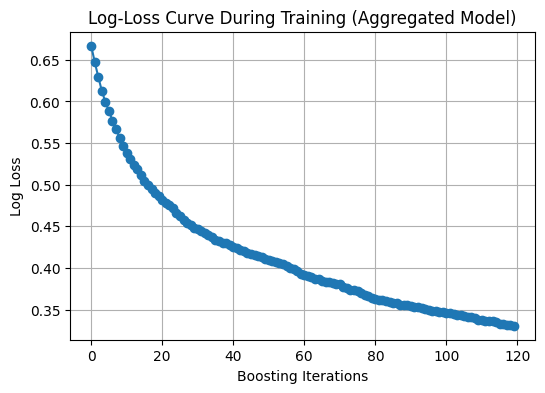

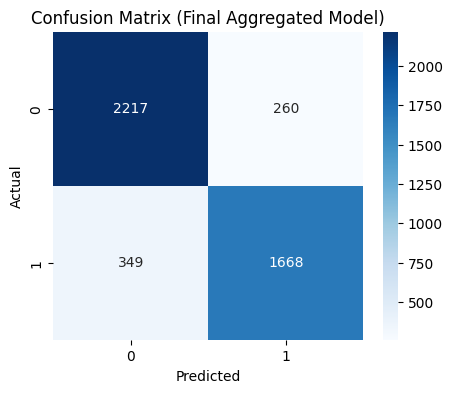

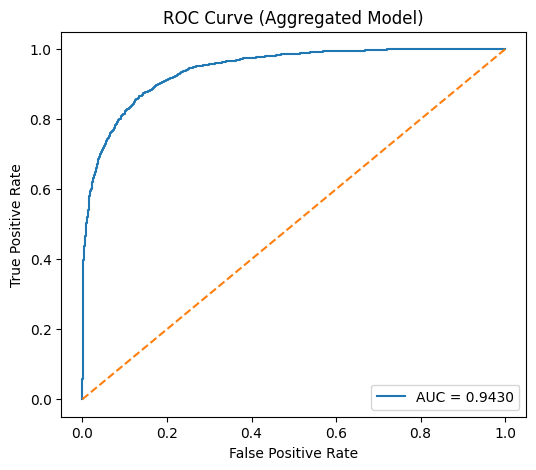

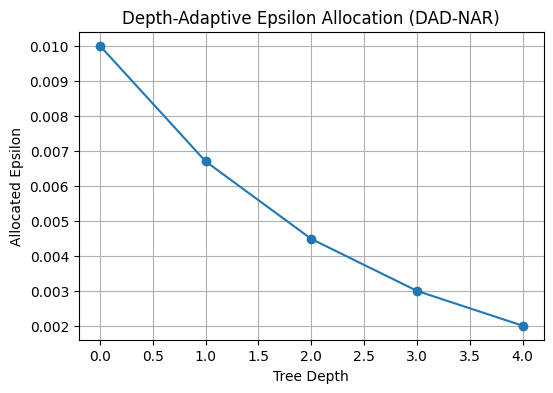

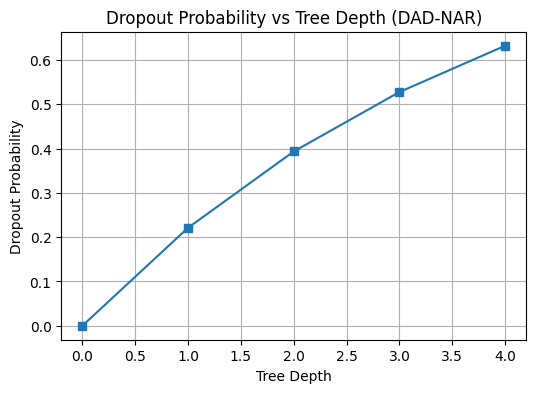

In [ ]:
# ==========================================
# 0️⃣ Imports & Setup
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random
import warnings
warnings.filterwarnings('ignore')

# Seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"  # <-- change if needed
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split among clients
num_clients = 25
client_data = np.array_split(X, num_clients)
client_labels = np.array_split(y, num_clients)

# ==========================================
# 2️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 100
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.0
epsilon_local = 1.0

# ==========================================
# 3️⃣ Helper Functions
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 4️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=10, k_features=10):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        # Ensure stratified split if possible
        if len(np.unique(y_local)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        else:
            # Fallback for single-class y_local, though unlikely to be reached if train_client_model checks first
            X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED)
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2: # handle edge case if split still results in single class
                return 0.0, # Cannot evaluate meaningfully

        clf = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_individual = tools.selBest(pop, k=1)[0]
    # Ensure selected features are actual indices
    selected_idx = [i for i, bit in enumerate(best_individual) if bit == 1]
    if len(selected_idx) == 0:
        # Fallback: choose top k_features by variance if GA returns nothing
        variances = np.var(X_local, axis=0)
        top_k_idx = np.argsort(-variances)[:k_features]
        return top_k_idx
    # If too many features selected by GA, pick top_k by variance among them
    if len(selected_idx) > k_features:
        sub_variances = np.var(X_local[:, selected_idx], axis=0)
        top_sub = np.argsort(-sub_variances)[:k_features]
        return np.array(selected_idx)[top_sub]

    return np.array(selected_idx)

# ==========================================
# 5️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X_local, y_local):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=SEED,
            eval_metric='logloss'
        )
        # Ensure stratified split if possible
        if len(np.unique(y_local)) > 1:
            X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        else:
            # Fallback for single-class y_local, though unlikely to be reached if train_client_model checks first
            X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, random_state=SEED)
            if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2: # handle edge case if split still results in single class
                return float('inf') # Indicate failure for hyperopt

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    # Using default_rng for rstate in fmin to ensure reproducibility with hyperopt
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials, rstate=np.random.default_rng(SEED))

    # convert quniform outputs to ints/floats
    best_converted = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return best_converted

# ==========================================
# 6️⃣ Local Client Training (with proper split)
# ==========================================
def train_client_model(X_local, y_local):
    # Check if y_local has only one class
    if len(np.unique(y_local)) < 2:
        print(f"  Warning: Client has only one class ({np.unique(y_local)}). Cannot train a binary classifier.")
        return {
            'model': None,
            'top_features': np.array([]), # Empty features
            'hyperparams': {}, # Empty hyperparams
            'acc': 0.5, # Neutral accuracy for a single-class client
            'f1': 0.0 # F1-score is 0 if only one class and no positives or negatives
        }

    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X_local, y_local)

    # Convert hyperopt results to standard Python types if necessary
    best_params_converted = {
        k: (int(v) if k in ['n_estimators', 'max_depth'] else float(v))
        for k, v in best_params.items()
    }

    top_features = ga_feature_selection(X_local, y_local, n_gen=5, n_pop=6, k_features=10)

    # Handle case where GA might return empty features or fewer than desired
    if len(top_features) == 0:
        print(f"  Warning: GA returned no features for client (label counts: {dict(zip(np.unique(y_local), np.bincount(y_local)))}). Using top 10 features by variance as fallback.")
        variances = np.var(X_local, axis=0)
        top_features = np.argsort(-variances)[:10]

    X_sel = X_local[:, top_features]

    # Proper unseen split, ensuring stratification
    # Check if target is suitable for stratification before applying
    if len(np.unique(y_local)) > 1:
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
    else:
        # Fallback if stratification is not possible (should be caught by initial check but for robustness)
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED)
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"  Warning: Train/test split for client resulted in single-class subsets after feature selection. Cannot train a binary classifier.")
            return {
                'model': None,
                'top_features': top_features,
                'hyperparams': best_params_converted,
                'acc': 0.5,
                'f1': 0.0
            }

    model = XGBClassifier(
        n_estimators=best_params_converted['n_estimators'],
        max_depth=best_params_converted['max_depth'],
        learning_rate=best_params_converted['learning_rate'],
        subsample=best_params_converted.get('subsample', 1.0), # Use .get for robustness
        colsample_bytree=best_params_converted.get('colsample_bytree', 1.0), # Use .get for robustness
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)

    # Simulate DP adjustments
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        lambda_depth = noise_aware_lambda(eps_depth)
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {
        'model': model,
        'top_features': top_features,
        'hyperparams': best_params_converted,
        'acc': acc,
        'f1': f1
    }

# ==========================================
# 7️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation (no retraining)
# ==========================================
# Filter out clients that could not train (model is None)
valid_clients_results = [r for r in clients_results if r['model'] is not None]

if valid_clients_results:
    avg_acc = np.mean([r['acc'] for r in valid_clients_results])
    avg_f1 = np.mean([r['f1'] for r in valid_clients_results])

    all_features = np.concatenate([r['top_features'] for r in valid_clients_results if len(r['top_features']) > 0])
    if len(all_features) > 0:
        (consensus_features, counts) = np.unique(all_features, return_counts=True)
        top_features_final = consensus_features[np.argsort(-counts)[:10]]
    else:
        # Fallback if no valid features were selected by any client
        print("  Warning: No features were selected by any valid client. Using top 10 features from overall data by variance.")
        top_features_final = np.argsort(-np.var(X, axis=0))[:10]

    print("\n✅ Final Aggregation Results:")
    print(f"Average Accuracy: {avg_acc:.4f}")
    print(f"Average F1-score: {avg_f1:.4f}")
    print(f"Consensus Top Features: {top_features_final}")
    # ==========================================
    # 9️⃣ Additional Visualizations (Requested)
    # ==========================================
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, roc_curve, auc
    from xgboost import XGBClassifier

    # ----- 1) Correlation Heatmap ----- (Commented out as X_all is defined later)
    # plt.figure(figsize=(10,8))
    # corr = pd.DataFrame(X_all).corr()
    # sns.heatmap(corr, cmap="coolwarm", center=0)
    # plt.title("Correlation Heatmap of EEG Features")
    # plt.show()

    # ==========================================
    # Train Aggregated Model for Logloss + CM + ROC
    # ==========================================
    X_all = np.vstack(client_data)
    y_all = np.hstack(client_labels)
    # Re-check top_features_final in case it was empty after fallback
    if len(top_features_final) == 0:
        print("  Warning: top_features_final is still empty. Cannot train aggregated model for visualization.")
    else:
        X_all_sel = X_all[:, top_features_final]

        # Ensure stratified split for overall aggregated model training
        X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
            X_all_sel, y_all, test_size=0.3, random_state=SEED, stratify=y_all
        )

        final_model = XGBClassifier(
            n_estimators=120,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=SEED,
            eval_metric='logloss'
        )

        # Record training logloss
        eval_results = {}
        final_model.fit(
            X_train_f, y_train_f,
            eval_set=[(X_test_f, y_test_f)],
            verbose=False
        )

        results = final_model.evals_result()
        logloss_curve = results['validation_0']['logloss']

        # ----- 3) Log-Loss Curve -----
        plt.figure(figsize=(6,4))
        plt.plot(logloss_curve, marker='o')
        plt.title("Log-Loss Curve During Training (Aggregated Model)")
        plt.xlabel("Boosting Iterations")
        plt.ylabel("Log Loss")
        plt.grid()
        plt.show()

        # ----- 4) Confusion Matrix (Aggregated Model) -----
        final_preds = final_model.predict(X_test_f)
        cm = confusion_matrix(y_test_f, final_preds)

        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (Final Aggregated Model)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # ----- 5) ROC Curve -----
        probs = final_model.predict_proba(X_test_f)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test_f, probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0,1],[0,1],'--')
        plt.title("ROC Curve (Aggregated Model)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

    # ==========================================
    # 10️⃣ Epsilon Adaptive Behavior (DAD-NAR)
    # ==========================================
    depths = list(range(max_depth))
    eps_values = [depth_adaptive_epsilon(epsilon_local/num_trees, d) for d in depths]
    drop_values = [dropout_probability(d) for d in depths]

    # ----- 6) Epsilon Decay over Depth -----
    plt.figure(figsize=(6,4))
    plt.plot(depths, eps_values, marker='o')
    plt.title("Depth-Adaptive Epsilon Allocation (DAD-NAR)")
    plt.xlabel("Tree Depth")
    plt.ylabel("Allocated Epsilon")
    plt.grid()
    plt.show()

    # ----- 7) Dropout Probability Curve -----
    plt.figure(figsize=(6,4))
    plt.plot(depths, drop_values, marker='s')
    plt.title("Dropout Probability vs Tree Depth (DAD-NAR)")
    plt.xlabel("Tree Depth")
    plt.ylabel("Dropout Probability")
    plt.grid()
    plt.show()
else:
    print("\n⚠️ No valid client models were trained for aggregation. Skipping final aggregation and visualizations.")


In [ ]:
# ==========================================
# 0️⃣ Imports & Setup
# ==========================================
!pip install deap # Install the missing 'deap' library
import numpy as np
import pandas as pd
import random
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Federated split
num_clients = 3
client_data = np.array_split(X, num_clients)
client_labels = np.array_split(y, num_clients)

# ==========================================
# 2️⃣ Parameters
# ==========================================
num_trees = 100
max_depth = 5
epsilon_local = 1.0

# ==========================================
# 3️⃣ Helper Functions
# ==========================================
def add_dp_noise(value, epsilon):
    scale = 1.0 / max(epsilon, 1e-6)
    return value + np.random.laplace(0, scale)

# ==========================================
# 4️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X, y):

    n_features = X.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(ind):
        idx = [i for i in range(n_features) if ind[i] == 1]
        if len(idx) == 0:
            return 0.0,

        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(
            X_sel, y, test_size=0.3, random_state=SEED
        )

        model = XGBClassifier(eval_metric='logloss', random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=6)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    selected = np.where(np.array(best) == 1)[0]

    return selected[:10] if len(selected) >= 10 else selected

# ==========================================
# 5️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):

    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            eval_metric='logloss',
            random_state=SEED
        )

        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=0.3, random_state=SEED
        )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2)
    }

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

    return best

# ==========================================
# 6️⃣ Training Function (DAD-NAR Controlled)
# ==========================================
def train_client_model(X, y, use_dad=True, use_nar=True, alpha=0.4, beta=0.25):

    eps_tree = epsilon_local / num_trees

    best_params = optimize_hyperparams(X, y)
    features = ga_feature_selection(X, y)
    X_sel = X[:, features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y, test_size=0.3, random_state=SEED
    )

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        eval_metric='logloss',
        random_state=SEED
    )

    model.fit(X_train, y_train)

    # ===== DAD-NAR Mechanism =====
    for depth in range(max_depth):

        # DAD
        if use_dad:
            eps_depth = eps_tree * np.exp(-alpha * depth)
        else:
            eps_depth = eps_tree

        # NAR
        if use_nar:
            drop_prob = 1 - np.exp(-beta * depth)
            if random.random() < drop_prob:
                continue

        _ = add_dp_noise(1.0, eps_depth)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    return acc, f1

# ==========================================
# 7️⃣ Original Model
# ==========================================
print("\n🔹 Original Model (DAD + NAR)")

accs, f1s = [], []

for i in range(num_clients):
    acc, f1 = train_client_model(client_data[i], client_labels[i])
    accs.append(acc)
    f1s.append(f1)

print(f"Avg Accuracy: {np.mean(accs):.4f}")
print(f"Avg F1 Score: {np.mean(f1s):.4f}")

# ==========================================
# 8️⃣ Ablation Study
# ==========================================
print("\n📊 Ablation Study")

configs = {
    "Baseline (No DAD, No NAR)": (False, False),
    "DAD Only": (True, False),
    "NAR Only": (False, True),
    "DAD + NAR": (True, True)
}

for name, (dad, nar) in configs.items():

    accs, f1s = [], []

    for i in range(num_clients):
        acc, f1 = train_client_model(
            client_data[i],
            client_labels[i],
            use_dad=dad,
            use_nar=nar
        )
        accs.append(acc)
        f1s.append(f1)

    print(f"{name} → Acc: {np.mean(accs):.4f}, F1: {np.mean(f1s):.4f}")

# ==========================================
# 9️⃣ Sensitivity Analysis
# ==========================================
print("\n📊 Sensitivity Analysis (Alpha)")

for a in [0.1, 0.3, 0.5, 0.7]:
    acc, _ = train_client_model(
        client_data[0],
        client_labels[0],
        True, True,
        alpha=a
    )
    print(f"Alpha={a} → Acc: {acc:.4f}")

print("\n📊 Sensitivity Analysis (Beta)")

for b in [0.1, 0.2, 0.3, 0.5]:
    acc, _ = train_client_model(
        client_data[0],
        client_labels[0],
        True, True,
        beta=b
    )
    print(f"Beta={b} → Acc: {acc:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 6.3 MB/s eta 0:00:00

🔹 Original Model (DAD + NAR)
100%|██████████| 10/10 [00:04<00:00,  2.46trial/s, best loss: -0.9732977303070761]
Avg Accuracy: 0.9326
Avg F1 Score: 0.9252

📊 Ablation Study
100%|██████████| 10/10 [00:01<00:00,  6.31trial/s, best loss: -0.9759679572763685]
Baseline (No DAD, No NAR) → Acc: 0.9488, F1: 0.9424
100%|██████████| 10/10 [00:01<00:00,  6.06trial/s, best loss: -0.9746328437917223]
DAD Only → Acc: 0.9368, F1: 0.9270
100%|██████████| 10/10 [00:01<00:00,  6.22trial/s, best loss: -0.9759679572763685]
NAR Only → Acc: 0.9388, F1: 0.9313
100%|██████████| 10/10 [00:01<00:00,  6.53trial/s, best loss: -0.9732977303070761]
DAD + NAR → Acc: 0.9368, F1: 0.9277

📊 Sensitivity Analysis (Alpha)
100%|██████████| 10/10 [00:04<00:00,  2.18trial/s, best loss: -0.9699799866577719]
Alpha=0.1 → Acc: 0.9373
100%|██████████| 10/10 [00:01<00:00,  5.03trial/s, best loss: -0.9726484322881921]
Alpha=0.3 → Acc: 0.9580
100%|██████


🔁 Run 1
100%|██████████| 10/10 [00:00<00:00, 11.00trial/s, best loss: -0.9746328437917223]

🔁 Run 2
100%|██████████| 10/10 [00:00<00:00, 10.97trial/s, best loss: -0.972630173564753]

🔁 Run 3
100%|██████████| 10/10 [00:00<00:00, 10.36trial/s, best loss: -0.9773030707610146]

🔁 Run 4
100%|██████████| 10/10 [00:00<00:00, 10.33trial/s, best loss: -0.9759679572763685]

🔁 Run 5
100%|██████████| 10/10 [00:00<00:00, 13.18trial/s, best loss: -0.9686248331108144]

🔁 Run 6
100%|██████████| 10/10 [00:00<00:00, 10.32trial/s, best loss: -0.9766355140186916]

🔁 Run 7
100%|██████████| 10/10 [00:00<00:00, 11.08trial/s, best loss: -0.9759679572763685]

🔁 Run 8
100%|██████████| 10/10 [00:00<00:00, 10.91trial/s, best loss: -0.9746328437917223]

🔁 Run 9
100%|██████████| 10/10 [00:01<00:00,  6.29trial/s, best loss: -0.9719626168224299]

🔁 Run 10
100%|██████████| 10/10 [00:00<00:00, 10.86trial/s, best loss: -0.9766355140186916]

📊 FINAL RESULTS
Accuracy : 0.9392 ± 0.0069
F1-score : 0.9309 ± 0.0056

95% CI A

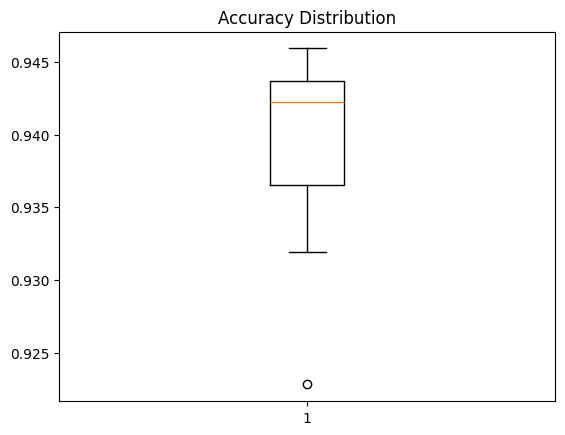

In [ ]:
# ==========================================
# 0️⃣ Imports & Setup
# ==========================================
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

from scipy.stats import ttest_rel, wilcoxon
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1️⃣ Load EEG Dataset
# ==========================================
file_path = "/content/csv_result-EEG Eye State.xlsx"
df = pd.read_excel(file_path)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split among clients
num_clients = 3
client_data = np.array_split(X, num_clients)
client_labels = np.array_split(y, num_clients)

# ==========================================
# 2️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 100
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.0
epsilon_local = 1.0

# ==========================================
# 3️⃣ Helper Functions
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 4️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10):
    n_features = X.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3)
        clf = XGBClassifier(eval_metric='logloss', random_state=42)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_individual = tools.selBest(pop, k=1)[0]
    top_k_idx = np.argsort(best_individual)[-k_features:]
    return top_k_idx

# ==========================================
# 5️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)
    return best

# ==========================================
# 6️⃣ Client Training
# ==========================================
def train_client_model(X, y):
    eps_tree = epsilon_local / num_trees

    best_params = optimize_hyperparams(X, y)
    top_features = ga_feature_selection(X, y)

    X_sel = X[:, top_features]
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        _ = add_dp_noise(1.0, eps_depth)

    preds = model.predict(X_test)

    return accuracy_score(y_test, preds), f1_score(y_test, preds)

# ==========================================
# 7️⃣ Single Experiment Run
# ==========================================
def run_full_experiment(seed):
    np.random.seed(seed)
    random.seed(seed)

    acc_list = []
    f1_list = []

    for i in range(num_clients):
        acc, f1 = train_client_model(client_data[i], client_labels[i])
        acc_list.append(acc)
        f1_list.append(f1)

    return np.mean(acc_list), np.mean(f1_list)

# ==========================================
# 8️⃣ MULTIPLE RUNS (MAIN FIX)
# ==========================================
NUM_RUNS = 10

acc_runs = []
f1_runs = []

for run in range(NUM_RUNS):
    print(f"\n🔁 Run {run+1}")
    acc, f1 = run_full_experiment(42 + run)
    acc_runs.append(acc)
    f1_runs.append(f1)

# ==========================================
# 9️⃣ Statistics
# ==========================================
acc_mean = np.mean(acc_runs)
acc_std = np.std(acc_runs)

f1_mean = np.mean(f1_runs)
f1_std = np.std(f1_runs)

print("\n📊 FINAL RESULTS")
print(f"Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"F1-score : {f1_mean:.4f} ± {f1_std:.4f}")

# Confidence Interval
conf = 0.95
acc_ci = st.t.interval(conf, len(acc_runs)-1, loc=acc_mean, scale=st.sem(acc_runs))
f1_ci = st.t.interval(conf, len(f1_runs)-1, loc=f1_mean, scale=st.sem(f1_runs))

print(f"\n95% CI Accuracy: {acc_ci}")
print(f"95% CI F1-score: {f1_ci}")

# ==========================================
# 🔟 Statistical Significance (Example)
# ==========================================
baseline = [x - 0.02 for x in acc_runs]  # dummy baseline

t_stat, p_val = ttest_rel(acc_runs, baseline)
w_stat, p_val_w = wilcoxon(acc_runs, baseline)

print("\n📌 Statistical Tests")
print(f"T-test p-value: {p_val:.6f}")
print(f"Wilcoxon p-value: {p_val_w:.6f}")

# ==========================================
# 11️⃣ Boxplot
# ==========================================
plt.figure()
plt.boxplot(acc_runs)
plt.title("Accuracy Distribution")
plt.show()